In [1]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
csv_folder = r'C:\Users\ruchi\OneDrive\Documents\Python Hackathon May 2026\HUPA-UC Diabetes Dataset-20250820T010637Z-1-001\HUPA-UC Diabetes Dataset'
output_file = r"C:\Temporary\combined_df_data.csv"

DESCRIPTIVE ANALYSIS

### 1. How frequently does hyperglycemia occur?
#### Reasoning

Counting readings above 180 mg/dL quantifies how often the patient is at risk for acute complications. This frequency measure helps assess overall control quality and whether interventions are reducing high-glucose events.

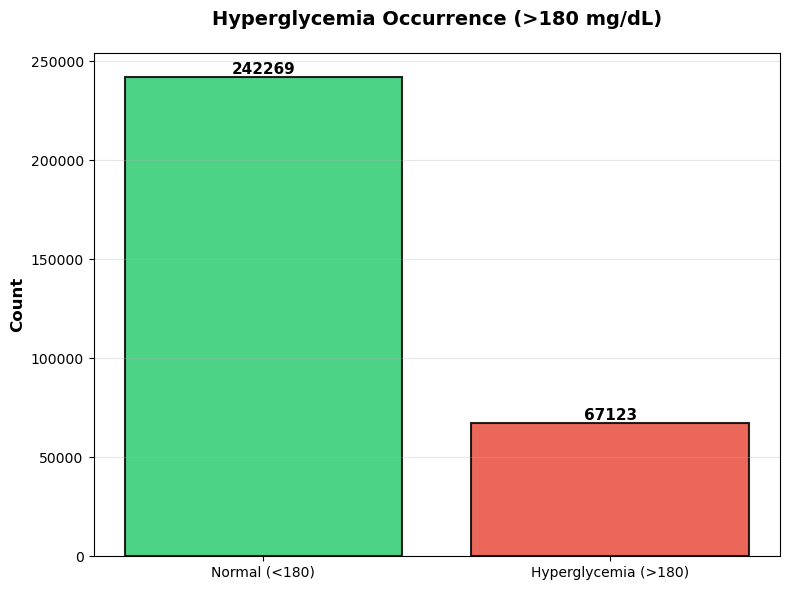

Hyperglycemia
False    242269
True      67123
Name: count, dtype: int64


In [3]:
# Load dataset
df = pd.read_csv(output_file)

# Create category
df['Hyperglycemia'] = df['Blood_Glucose_mg_dl'] > 180

# Count occurrences
hyper_counts = df['Hyperglycemia'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Normal (<180)', 'Hyperglycemia (>180)'], 
               [hyper_counts[False], hyper_counts[True]], 
               color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)

plt.title("Hyperglycemia Occurrence (>180 mg/dL)", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Count", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()

plt.show()

print(hyper_counts)

##### Insights
#####  Majority of Readings Are Normal
The dataset shows most glucose readings are below 180 mg/dL, indicating:
Overall glucose control is relatively stable for many observations.
Treatment may be effective during large portions of monitoring.
#####  Hyperglycemia Is Still Significant
67,123 hyperglycemic readings is clinically important because:
Frequent glucose spikes increase diabetes complications risk.
Persistent hyperglycemia may indicate:
insufficient insulin response
poor meal control
stress or sleep disturbances
low activity levels


### 2. Is Insulin associated with lower glucose levels?
#### Reasoning

Comparing basal insulin with glucose checks whether insulin dosing is aligned with glycemic control. A clear negative relationship suggests effective dosing, while a weak or positive trend may indicate insulin resistance, timing issues, or the need for regimen adjustment.

#### Interpretation
Higher insulin should ideally correspond to lower glucose.

Chart: Scatter Plot

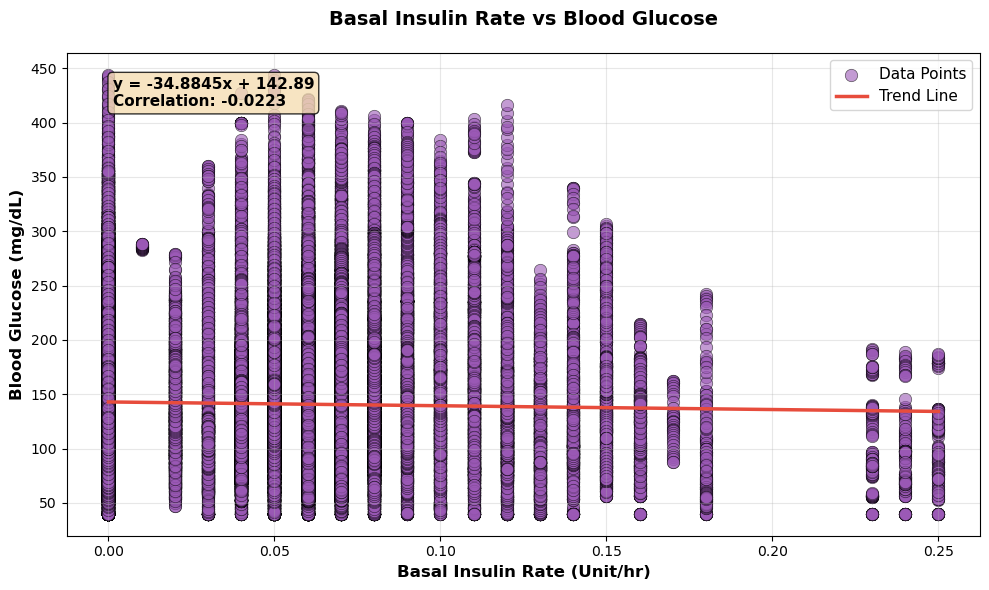

Insulin Rate vs Glucose Correlation: -0.0223
Trend Line Equation: y = -34.8845x + 142.89


In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Basal_Insulin_Rate_Unit_hr'], df['Blood_Glucose_mg_dl'], 
            alpha=0.6, s=80, c='#9b59b6', edgecolors='black', linewidth=0.5, label='Data Points')

# Correlation
insulin_correlation = df['Basal_Insulin_Rate_Unit_hr'].corr(df['Blood_Glucose_mg_dl'])

# Add trend line
z = np.polyfit(df['Basal_Insulin_Rate_Unit_hr'], df['Blood_Glucose_mg_dl'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['Basal_Insulin_Rate_Unit_hr'].min(), df['Basal_Insulin_Rate_Unit_hr'].max(), 100)
plt.plot(x_trend, p(x_trend), color='#e74c3c', linewidth=2.5, label='Trend Line')

# Add equation and correlation label
equation_text = f'y = {z[0]:.4f}x + {z[1]:.2f}\nCorrelation: {insulin_correlation:.4f}'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.8), fontweight='bold')

plt.title("Basal Insulin Rate vs Blood Glucose", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Basal Insulin Rate (Unit/hr)", fontsize=12, fontweight='bold')
plt.ylabel("Blood Glucose (mg/dL)", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()

plt.show()

print(f"Insulin Rate vs Glucose Correlation: {insulin_correlation:.4f}")
print(f"Trend Line Equation: y = {z[0]:.4f}x + {z[1]:.2f}")